<a href="https://colab.research.google.com/github/Shri1911/research-project_jpynb/blob/main/M505_Shri_Ram_GH1052746.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment (Individual Project)

Heading - Designing and Reviewing a standard machine learning pipeline,
Student Name - Shri Ram Muraleedharan,
Student Number - GH1052746,
Subject - M505C - Into to AI & Machine Learning,
Professor - Trung Nghia Duong

                Data Information

Data - Medical Cost Personal Dataset
Source - Kaggle
Hyperlink -https://www.kaggle.com/datasets/mirichoi0218/insurance
Description - The dataset contains 1338 samples and 7 Attributes.

              Introduction                                                 

Problem Statement - The company aims in accurately anticipating it's future insurance costs. So, the biggest challenege faced by the company is predicting the individual medical expenditure costs depending on the 7 variables. Having a better idea about these expenses, the company can perform hassle-free data driven decisions and can also cut unecessary spending on individual's insurance.

In a real world scenario, the necessary datas could be gathered through patient declaration slips, patient historical directory and health insurance policies. The issue can then be drafted as a 'supervised machine learning task'.

Data Exploration - The Datafile contains 1338 samples, having 7 variables.The datasets are divided into two features - they are 'numerical' and 'categorical'. There was no missing values in the data exploration while one duplicated record was found. The evaluation matrics used are MAE, RMSE & R2.

Data preprocessing and feature engineering - The data features were broadly classified into numerical and categorical. Non numerical values were converted using OneHotEncoder. There is also comparison between two preprocessing approaches using Linear Regression and Cross Validation. Standard scaler was applied for Numeric features.

Model Training - The two Machine Learning algorithms trained were "Linear Regression" & "Random Forest Regressor". Whole data was divided into two sets - 80% training & 20% test.

Hyperparameter Tuning & Interpretation - I used GridSearchCV with cross-validation to investigate the impact of hyperparameter settings on the Random Forest Model. I tested Various parameters against the no: of trees (n_estimators) & its maximum depth(max_depth). The selected parameters should be reported from grid_rf.best_params when the notebook is run. I also avoided unrestricted memorized data. The cross-validation result supports a more cautious conclusion that the tested unrestricted setting generalised less effectively.

Final Evaluation & Interpretation - I evaluated both the models with test set utilising Mean Absolute Error, Root Mean Squared Error & R^{2} score. The R^{2} score is more accurate as it suggests the proportion of variance in insurance costs.

Visualization and Discussion - I plotted the actual insurance charges vs predicted insurance charges to have a visual display on the Random Forest. Points close to black diagonal line showed more accurate predictions while wider dots indicate higher errors.

Conclusion -
Base Summary - Random Forest Aggresor performed much better than Linear Regression Model as it defines the deviations in the medical charges. Hence it is the best model.

Limitations - There are a number of restrictions to be aware of. Because the dataset includes smaller number of variables, it is unable to fully capture all the variables related to actual medical expenditures. It also seems more difficult to forecast the high-charge observations. Furthermore, this model's effectiveness over these datas are insufficient to support actual insurance implementation. Validation of representative current data, monitoring, governance, fairness evaluation, and suitable human oversight would all be necessary for a production system.

Future Scope - In my future research, I would evaluate different regression models, look more closely at residuals, and look into how variables like BMI and smoking status influence each other.

References - Dataset source: Kaggle website - Kaggle Medical Cost Personal Datasets. https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
scikit learn documentation: preprocessing, pipelines, model selection, regression models and evaluation metrics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

RANDOM_STATE = 42
#Load Dataset from URL
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
display (df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Dataset Shape: (1338, 7)

Feature Types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1


<function matplotlib.pyplot.show(close=None, block=None)>

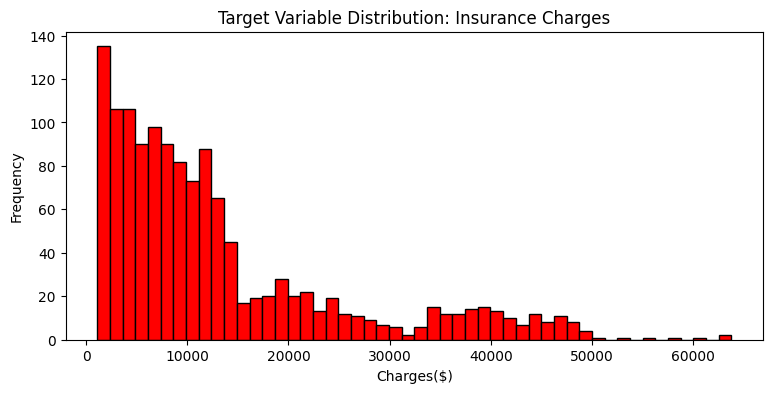

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Load Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
display (df.head())
print ("Dataset Shape:",df.shape)
print ("\nFeature Types:\n", df.dtypes)
print ("\nMissing Values:\n",df.isnull().sum())
print ("\nDuplicate Rows:", df.duplicated().sum())

#Drop the single duplicate row
df = df.drop_duplicates()

#Visualize the target variable distribution
plt.figure(figsize=(9,4))
plt.hist(df['charges'], bins=50, color='red', edgecolor='black')
plt.title("Target Variable Distribution: Insurance Charges")
plt.xlabel('Charges($)')
plt.ylabel('Frequency')
plt.show

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Define feature groups
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

#Pipeline A: Encoding only (No Scaling)
preprocessor_unscaled = ColumnTransformer(transformers= [('num', 'passthrough', numeric_features),('cat', OneHotEncoder(drop='first'), categorical_features)])

#Pipeline B: Scaling and Encoding
numeric_pipeline_scaled = Pipeline(steps=[('scaler', StandardScaler())])
preprocessor_scaled = ColumnTransformer(transformers=[('num', numeric_pipeline_scaled, numeric_features),
                                                      ('cat', OneHotEncoder(drop='first'), categorical_features)])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score

#Load Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
x = df.drop('charges', axis=1)
y = df['charges']

# Define preprocessors for numerical and categorical features
numeric_features = x.select_dtypes(include=np.number).columns
categorical_features = x.select_dtypes(include='object').columns

# Preprocessor for unscaled model (only one-hot encoding for categorical)
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Preprocessor for scaled model (scaling numerical, one-hot encoding categorical)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Option A Model
clf_unscaled = Pipeline(steps=[('preprocessor', preprocessor_unscaled),
                               ('model', LinearRegression())])

# Option B Model
clf_scaled = Pipeline(steps=[('preprocessor', preprocessor_scaled),
                               ('model', LinearRegression())])

# Compare using cross-validation (R2 Score)
Score_A = cross_val_score(clf_unscaled, x, y, cv=5, scoring='r2').mean()
Score_B = cross_val_score(clf_scaled, x, y, cv=5, scoring='r2').mean()

print(f"Option A (Unscaled) R2 Score: {Score_A: .4f}")
print(f"Option B (Scaled) R2 Score: {Score_B: .4f}")

Option A (Unscaled) R2 Score:  0.7469
Option B (Scaled) R2 Score:  0.7469


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
#Load Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
X = df.drop('charges', axis=1)
Y = df['charges']

# Define preprocessors for numerical and categorical features
numeric_features = x.select_dtypes(include=np.number).columns
categorical_features = x.select_dtypes(include='object').columns

# Preprocessor for scaled model (scaling numerical, one-hot encoding categorical)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])
RANDOM_STATE = 42 # Define RANDOM_STATE

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_STATE)

# Initialize Pipelines (Corrected syntax and moved from pXLThqXR_j5Y)
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor_scaled), ('model', LinearRegression())])
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor_scaled), ('model', RandomForestRegressor(random_state=RANDOM_STATE))])

param_grid_rf = { 'model__n_estimators': [50, 100, 200], 'model__max_depth': [3, 5, 10, None] }
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='r2')
grid_rf.fit(X_train, Y_train)

# Fit baseline Linear Regression for comparison
pipeline_lr.fit(X_train, Y_train)

print("Best Random Forest Params:", grid_rf.best_params_)
print("Best RF CV R2 Score:", grid_rf.best_score_)

Best Random Forest Params: {'model__max_depth': 3, 'model__n_estimators': 100}
Best RF CV R2 Score: 0.8454413297045565


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_lr = pipeline_lr.predict(X_test)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Linear Regression Results:")
print("MAE: ${mean_absolute_error(Y_test, y_pred_lr): .2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R2 Score: {r2_score(Y_test, y_pred_lr): .4f}")

print("\nRandom Forest Results:")




Linear Regression Results:
MAE: ${mean_absolute_error(Y_test, y_pred_lr): .2f}
RMSE: $5796.28
R2 Score:  0.7836

Random Forest Results:


Text(0, 0.5, 'Predicted Charges ($)')

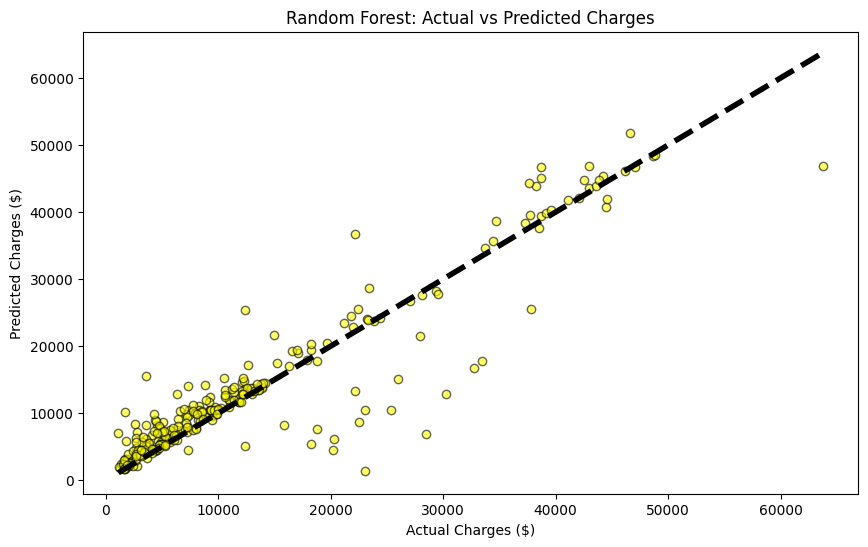

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#Load Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df = pd.get_dummies(df, drop_first=True, dtype=int)
x = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model_rf= RandomForestRegressor(random_state=42)
model_rf.fit(X_train, Y_train)
Y_pred_rf = model_rf.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred_rf, alpha=0.6, color = 'yellow', edgecolor='black')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=4)
plt.title("Random Forest: Actual vs Predicted Charges")
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")